In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import linalg as LA

# ========================================
# DONNÉES (MÊMES QUE TP1)
# ========================================
X = np.array([
    [1881.9,  96.8, 14.2, 25.2, 1135.5, 278.3],
    [3369.8,  96.8, 10.8, 51.6, 1331.7, 284.0],
    [4467.4, 138.2,  9.5, 34.2, 2346.1, 312.3],
    [1862.1,  83.2,  8.8, 27.6,  972.6, 203.4],
    [3499.8, 287.0, 11.5, 49.4, 2139.4, 358.0],
    [3903.2, 170.7,  6.3, 42.0, 1935.2, 292.9],
    [2620.7, 129.5,  4.2, 16.8, 1346.0, 131.8],
    [3678.4, 157.0,  6.0, 24.9, 1682.6, 194.2],
    [3840.5, 187.9, 10.2, 39.6, 1859.9, 449.1],
    [2170.2, 140.5, 11.7, 31.1, 1351.1, 256.5],
    [3920.4, 128.0,  7.2, 25.5, 1911.5,  64.1],
    [2599.6,  39.6,  5.5, 19.4, 1050.8, 172.5],
    [2828.5, 211.3,  9.9, 21.8, 1085.0, 209.0],
    [2498.7, 123.2,  7.4, 26.5, 1086.2, 153.5],
    [2685.1,  41.2,  2.3, 10.6,  812.5,  89.8],
    [2739.3, 100.7,  6.6, 22.0, 1270.4, 180.5],
    [1662.1,  81.1, 10.1, 19.1,  872.2, 123.3],
    [2469.9, 142.9, 15.5, 30.9, 1165.5, 335.5],
    [2350.7,  38.7,  2.4, 13.5, 1253.1, 170.0],
    [3177.7, 292.1,  8.0, 34.8, 1400.0, 358.9]
])

villes = [f'V{i+1}' for i in range(20)]
sports = ['Hand', 'Basket', 'Tennis', 'Gym', 'Nata', 'Foot']

def titre_question(texte):
    print(f"\n\n### {texte} ###\n")

# Pour avoir de belles valeurs (4 décimales, pas d'exposant)
np.set_printoptions(precision=4, suppress=True)

print("la matrice =\n", X)
print("\n" + "#"*40)

n, p = X.shape
print("#"*40)
print("Nombre d'individus (villes) =", n)
print("Nombre de variables (sports) =", p)


la matrice =
 [[1881.9   96.8   14.2   25.2 1135.5  278.3]
 [3369.8   96.8   10.8   51.6 1331.7  284. ]
 [4467.4  138.2    9.5   34.2 2346.1  312.3]
 [1862.1   83.2    8.8   27.6  972.6  203.4]
 [3499.8  287.    11.5   49.4 2139.4  358. ]
 [3903.2  170.7    6.3   42.  1935.2  292.9]
 [2620.7  129.5    4.2   16.8 1346.   131.8]
 [3678.4  157.     6.    24.9 1682.6  194.2]
 [3840.5  187.9   10.2   39.6 1859.9  449.1]
 [2170.2  140.5   11.7   31.1 1351.1  256.5]
 [3920.4  128.     7.2   25.5 1911.5   64.1]
 [2599.6   39.6    5.5   19.4 1050.8  172.5]
 [2828.5  211.3    9.9   21.8 1085.   209. ]
 [2498.7  123.2    7.4   26.5 1086.2  153.5]
 [2685.1   41.2    2.3   10.6  812.5   89.8]
 [2739.3  100.7    6.6   22.  1270.4  180.5]
 [1662.1   81.1   10.1   19.1  872.2  123.3]
 [2469.9  142.9   15.5   30.9 1165.5  335.5]
 [2350.7   38.7    2.4   13.5 1253.1  170. ]
 [3177.7  292.1    8.    34.8 1400.   358.9]]

########################################
########################################
No

In [3]:
# ============================================================
# Q1 : MATRICE UTILISÉE, VALEURS PROPRES ET VECTEURS PROPRES
# ============================================================
titre_question("Q1 :MATRICE UTILISÉE, VALEURS PROPRES ET VECTEURS PROPRES")
# Théorie :
# On fait une ACP NORMEE => on travaille sur la matrice de corrélation R
# 1) Centrer : c_ij = x_ij - moyenne_j
# 2) Réduire : z_ij = c_ij / sigma_j
# 3) R = (1/n) * Z^T * Z
# Valeurs propres λk et vecteurs propres vk issus de R donnent :
#  - λk : part d'inertie (variance) expliquée par l'axe k
#  - vk : direction de l'axe factoriel k (combinaison linéaire des variables)

def calcule_centre(m):
    """Calcule le vecteur des moyennes par variable (centre de gravité)."""
    g = np.zeros(m.shape[1])
    for j in range(m.shape[1]):
        g[j] = np.mean(m[:, j])
    return g


B = calcule_centre(X)
print("\nmatrice_centree B =\n", B)









### Q1 :MATRICE UTILISÉE, VALEURS PROPRES ET VECTEURS PROPRES ###


matrice_centree B =
 [2911.3    134.32     8.405   28.325 1400.365  230.88 ]


In [4]:
def matrice_centree(m):
    """Retourne la matrice centrée C = X - g (en colonne)."""
    g = calcule_centre(m)
    c = np.zeros(m.shape)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            c[i, j] = m[i, j] - g[j]
    return c

A = matrice_centree(X)
print("\nmatrice_centree A =\n", A)






matrice_centree A =
 [[-1029.4     -37.52      5.795    -3.125  -264.865    47.42 ]
 [  458.5     -37.52      2.395    23.275   -68.665    53.12 ]
 [ 1556.1       3.88      1.095     5.875   945.735    81.42 ]
 [-1049.2     -51.12      0.395    -0.725  -427.765   -27.48 ]
 [  588.5     152.68      3.095    21.075   739.035   127.12 ]
 [  991.9      36.38     -2.105    13.675   534.835    62.02 ]
 [ -290.6      -4.82     -4.205   -11.525   -54.365   -99.08 ]
 [  767.1      22.68     -2.405    -3.425   282.235   -36.68 ]
 [  929.2      53.58      1.795    11.275   459.535   218.22 ]
 [ -741.1       6.18      3.295     2.775   -49.265    25.62 ]
 [ 1009.1      -6.32     -1.205    -2.825   511.135  -166.78 ]
 [ -311.7     -94.72     -2.905    -8.925  -349.565   -58.38 ]
 [  -82.8      76.98      1.495    -6.525  -315.365   -21.88 ]
 [ -412.6     -11.12     -1.005    -1.825  -314.165   -77.38 ]
 [ -226.2     -93.12     -6.105   -17.725  -587.865  -141.08 ]
 [ -172.      -33.62     -1.805  

In [5]:
def matrice_centree_reduite(m):
    """Retourne la matrice centrée-réduite Z (moyenne 0, variance 1)."""
    C = matrice_centree(m)
    Z = np.zeros(m.shape)
    for j in range(m.shape[1]):
        sigma = np.std(m[:, j], ddof=0)    # écart-type de la variable j
        for i in range(m.shape[0]):
            Z[i, j] = C[i, j] / sigma
    return Z

Z = matrice_centree_reduite(X)
print("\nMatrice centrée-réduite Z =\n", Z)


Matrice centrée-réduite Z =
 [[-1.3446 -0.5434  1.6894 -0.289  -0.626   0.4807]
 [ 0.5989 -0.5434  0.6982  2.1526 -0.1623  0.5385]
 [ 2.0326  0.0562  0.3192  0.5433  2.2352  0.8253]
 [-1.3705 -0.7404  0.1152 -0.0671 -1.011  -0.2786]
 [ 0.7687  2.2115  0.9023  1.9491  1.7466  1.2886]
 [ 1.2956  0.5269 -0.6137  1.2647  1.264   0.6287]
 [-0.3796 -0.0698 -1.2259 -1.0659 -0.1285 -1.0043]
 [ 1.002   0.3285 -0.7011 -0.3168  0.667  -0.3718]
 [ 1.2137  0.7761  0.5233  1.0428  1.0861  2.212 ]
 [-0.968   0.0895  0.9606  0.2566 -0.1164  0.2597]
 [ 1.3181 -0.0915 -0.3513 -0.2613  1.208  -1.6906]
 [-0.4072 -1.3719 -0.8469 -0.8254 -0.8262 -0.5918]
 [-0.1082  1.115   0.4358 -0.6035 -0.7453 -0.2218]
 [-0.5389 -0.1611 -0.293  -0.1688 -0.7425 -0.7844]
 [-0.2955 -1.3488 -1.7798 -1.6393 -1.3894 -1.4301]
 [-0.2247 -0.487  -0.5262 -0.585  -0.3072 -0.5107]
 [-1.6317 -0.7709  0.4941 -0.8532 -1.2483 -1.0905]
 [-0.5766  0.1243  2.0684  0.2381 -0.5551  1.0605]
 [-0.7323 -1.385  -1.7506 -1.3711 -0.348  -0.6171]
 


Matrice de corrélation R =
 [[ 1.      0.4518 -0.1059  0.5173  0.8651  0.3525]
 [ 0.4518  1.      0.3535  0.5904  0.53    0.6192]
 [-0.1059  0.3535  1.      0.5344  0.101   0.5859]
 [ 0.5173  0.5904  0.5344  1.      0.5977  0.7501]
 [ 0.8651  0.53    0.101   0.5977  1.      0.468 ]
 [ 0.3525  0.6192  0.5859  0.7501  0.468   1.    ]]

=> C'est cette matrice R que l'on diagonalise pour l'ACP normée.


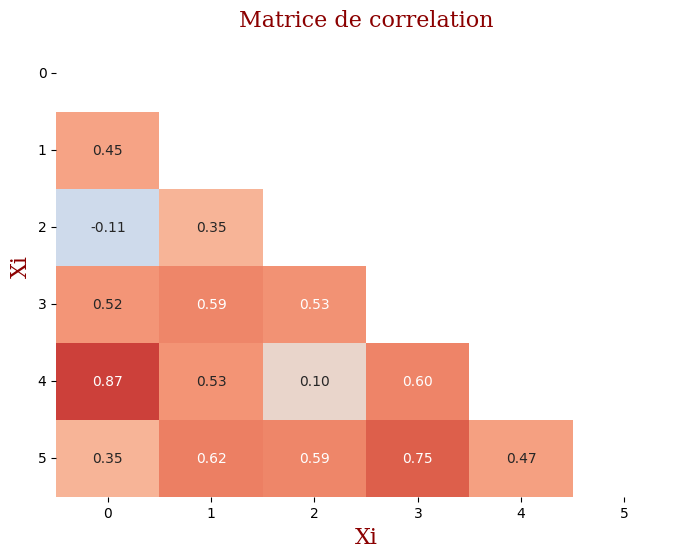


Valeurs propres (non triées) =
 [3.4859 1.4219 0.4728 0.1064 0.2943 0.2187]

Vecteurs propres (lignes = axes factoriels) =
 [[-0.3767 -0.4219 -0.2684 -0.4741 -0.4298 -0.4457]
 [-0.5533  0.0451  0.6489  0.1349 -0.412   0.288 ]
 [-0.1686  0.8757 -0.2686 -0.3014 -0.2044 -0.007 ]
 [ 0.7194  0.0098  0.2317 -0.1488 -0.6374  0.0163]
 [-0.0664 -0.1854 -0.5988  0.2447 -0.3358  0.6557]
 [ 0.0412 -0.1369  0.1501 -0.7643  0.291   0.5368]]


In [6]:
def calcule_correlation(m):
    """Calcule la matrice de corrélation R = (1/n) * Z^T * Z."""
    n = m.shape[0]
    return (1/n) * np.matmul(m.T, m)

R = calcule_correlation(Z)
print("\nMatrice de corrélation R =\n", R)
print("\n=> C'est cette matrice R que l'on diagonalise pour l'ACP normée.")

# ==== représentation graphique type heatmap triangulaire ====
plt.figure(figsize=(8,6))

# on construit un masque pour n'afficher que le triangle inférieur
mask = np.triu(np.ones_like(R, dtype=bool))

font = {
    'family': 'serif',
    'color':  'darkred',
    'weight': 'normal',
    'size':   16
}

sns.heatmap(R,
            mask=mask,
            vmin=-1, vmax=1,
            cmap='coolwarm',
            annot=True,          # afficher les valeurs dans les cases
            fmt=".2f",           # 2 décimales comme sur ton image
            cbar=False)

plt.title("Matrice de correlation", fontdict=font)
plt.xlabel("Xi", fontdict=font)
plt.ylabel("Xi", fontdict=font)
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.show()
# ================================================

# Détermination des valeurs propres et vecteurs propres de R
valp, vecp = LA.eig(R)

print("\nValeurs propres (non triées) =\n", valp)
print("\nVecteurs propres (lignes = axes factoriels) =\n", vecp.T)


In [7]:
# ============================================================
# Q2 : TEST "v EST-IL VECTEUR PROPRE ASSOCIE A λ D'UNE MATRICE A ?"
# ============================================================
titre_question("Q2 : TEST v EST-IL VECTEUR PROPRE ASSOCIE A λ D'UNE MATRICE ")

def est_vecteur_propre(A, v, lamb, eps=1e-6):
    diff = np.matmul(A, v) - lamb * v
    norme = LA.norm(diff)
    return norme < eps, norme

texte_q2 = "\n--- Vérification des couples (λk, vk) pour R ---\n\n"

for k in range(len(valp)):          # ici 6 axes
    lamb_k = valp[k]
    v_k    = vecp[:, k]
    ok, err = est_vecteur_propre(R, v_k, lamb_k)

    texte_q2 += f"Axe {k+1} :\n"
    texte_q2 += f"  - valeur propre λ{k+1} = {lamb_k:.4f}\n"
    texte_q2 += f"  - norme ||R v{k+1} - λ{k+1} v{k+1}|| = {err:.10f}\n"
    if ok:
        texte_q2 += (
            f"  - Conclusion : v{k+1} est bien un vecteur propre de R "
            f"associé à λ{k+1}.\n"
            "    (l'erreur est très proche de 0, due uniquement aux "
            "arrondis numériques.)\n\n"
        )
    else:
        texte_q2 += (
            f"  - Conclusion : v{k+1} n'est PAS un vecteur propre de R "
            f"pour cette valeur propre.\n\n"
        )

print(texte_q2)

print("# Intérêt :")
print("# - Vérifier la définition : A v ≈ λ v (ici A = R).")
print("# - Vérifier que la décomposition propre retournée par l'algorithme est correcte.")




### Q2 : TEST v EST-IL VECTEUR PROPRE ASSOCIE A λ D'UNE MATRICE  ###


--- Vérification des couples (λk, vk) pour R ---

Axe 1 :
  - valeur propre λ1 = 3.4859
  - norme ||R v1 - λ1 v1|| = 0.0000000000
  - Conclusion : v1 est bien un vecteur propre de R associé à λ1.
    (l'erreur est très proche de 0, due uniquement aux arrondis numériques.)

Axe 2 :
  - valeur propre λ2 = 1.4219
  - norme ||R v2 - λ2 v2|| = 0.0000000000
  - Conclusion : v2 est bien un vecteur propre de R associé à λ2.
    (l'erreur est très proche de 0, due uniquement aux arrondis numériques.)

Axe 3 :
  - valeur propre λ3 = 0.4728
  - norme ||R v3 - λ3 v3|| = 0.0000000000
  - Conclusion : v3 est bien un vecteur propre de R associé à λ3.
    (l'erreur est très proche de 0, due uniquement aux arrondis numériques.)

Axe 4 :
  - valeur propre λ4 = 0.1064
  - norme ||R v4 - λ4 v4|| = 0.0000000000
  - Conclusion : v4 est bien un vecteur propre de R associé à λ4.
    (l'erreur est très proche de 0, due uniquement aux arro



### Q3 :DIAGRAMME DES VALEURS PROPRES  ###



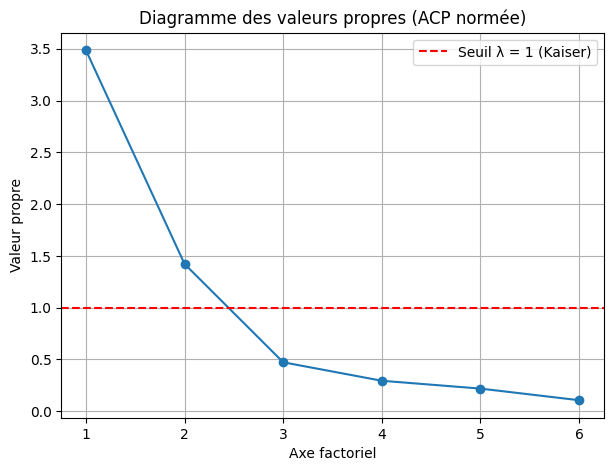

In [8]:
# Q3 : DIAGRAMME DES VALEURS PROPRES (SCREE PLOT)
# ============================================================
titre_question("Q3 :DIAGRAMME DES VALEURS PROPRES ")
# Théorie :
# On trie les valeurs propres par ordre décroissant.
# Critère de Kaiser dans une ACP normée : garder les λk > 1.

valp_sorted = np.sort(valp)[::-1]

plt.figure(figsize=(7,5))
plt.plot(range(1, len(valp_sorted)+1), valp_sorted, marker='o')
plt.axhline(1, color='red', linestyle='--', label="Seuil λ = 1 (Kaiser)")
plt.title("Diagramme des valeurs propres (ACP normée)")
plt.xlabel("Axe factoriel")
plt.ylabel("Valeur propre")
plt.grid(True)
plt.legend()
plt.show()

# Intérêt :
# - Visualiser la décroissance des λk (rupture de pente)
# - Repérer les axes importants (λk grands) et les axes négligeables

In [9]:
# ============================================================
# Q4 : TABLEAU (λk, TAUX D'INERTIE, TAUX D'INERTIE CUMULÉE)
# ============================================================
titre_question("Q4 : TAUX D'INERTIE ET TAUX CUMULÉS")

# Rappel théorique :
# - On travaille avec les valeurs propres triées par ordre décroissant.
# - TI_k (taux d'inertie de l'axe k) :
#       TI_k = λk / (somme_j λj)
#   => part de la variance totale expliquée par l'axe k.
# - TC_k (taux d'inertie cumulée) :
#       TC_k = somme_{j=1..k} TI_j
#   => part totale de variance expliquée par les k premiers axes.

# 1) Valeurs propres triées
valp_sorted = np.sort(valp)[::-1]

print("1) Valeurs propres triées (ordre décroissant) :\n")
for i, lam in enumerate(valp_sorted, start=1):
    print(f"Axe {i} : λ{i} = {lam:.4f}")
print("\nInterprétation : plus λk est grand, plus l'axe Fk explique d'inertie.\n")

# 2) Taux d'inertie expliquée TI_k
variance_expliquee = valp_sorted / np.sum(valp_sorted)    # TI_k

print("2) Taux d'inertie expliquée TI_k pour chaque axe :\n")
for i, ti in enumerate(variance_expliquee, start=1):
    print(f"Axe {i} : TI_{i} = {ti*100:.2f} %")
print("\nInterprétation : TI_k mesure la proportion de la variance totale")
print("expliquée par l'axe k. Un TI_k élevé signifie un axe très important.\n")

# 3) Taux d'inertie cumulée TC_k
variance_cumulee = np.cumsum(variance_expliquee)          # TC_k

print("3) Taux d'inertie cumulée TC_k :\n")
for i, tc in enumerate(variance_cumulee, start=1):
    print(f"Axe {i} : TC_{i} = {tc*100:.2f} %")
print("\nInterprétation : TC_k indique la part totale de variance")
print("expliquée par les k premiers axes. On choisit k tel que TC_k")
print("atteigne un seuil (par ex. 80 %) pour retenir la dimension du sous-espace.\n")

# 4) Tableau récapitulatif
print("4) Tableau récapitulatif (λk, TI_k, TC_k) :\n")
print("Axe\tλk\t\tTI_k (%)\tTC_k (%)")
for i in range(len(valp_sorted)):
    lam = valp_sorted[i]
    ti  = variance_expliquee[i] * 100
    tc  = variance_cumulee[i]   * 100
    print(f"{i+1}\t{lam:.4f}\t{ti:.2f}\t\t{tc:.2f}")

print("\nRésumé Q4 :")
print("- TI_k donne l'importance relative de chaque axe pris isolément.")
print("- TC_k sert à décider combien d'axes garder pour expliquer une")
print("  proportion donnée de l'inertie totale (par exemple 80 %).")




### Q4 : TAUX D'INERTIE ET TAUX CUMULÉS ###

1) Valeurs propres triées (ordre décroissant) :

Axe 1 : λ1 = 3.4859
Axe 2 : λ2 = 1.4219
Axe 3 : λ3 = 0.4728
Axe 4 : λ4 = 0.2943
Axe 5 : λ5 = 0.2187
Axe 6 : λ6 = 0.1064

Interprétation : plus λk est grand, plus l'axe Fk explique d'inertie.

2) Taux d'inertie expliquée TI_k pour chaque axe :

Axe 1 : TI_1 = 58.10 %
Axe 2 : TI_2 = 23.70 %
Axe 3 : TI_3 = 7.88 %
Axe 4 : TI_4 = 4.91 %
Axe 5 : TI_5 = 3.64 %
Axe 6 : TI_6 = 1.77 %

Interprétation : TI_k mesure la proportion de la variance totale
expliquée par l'axe k. Un TI_k élevé signifie un axe très important.

3) Taux d'inertie cumulée TC_k :

Axe 1 : TC_1 = 58.10 %
Axe 2 : TC_2 = 81.80 %
Axe 3 : TC_3 = 89.68 %
Axe 4 : TC_4 = 94.58 %
Axe 5 : TC_5 = 98.23 %
Axe 6 : TC_6 = 100.00 %

Interprétation : TC_k indique la part totale de variance
expliquée par les k premiers axes. On choisit k tel que TC_k
atteigne un seuil (par ex. 80 %) pour retenir la dimension du sous-espace.

4) Tableau récapitulat

In [10]:
# ============================================================
# Q5 : DIMENSION DU SOUS-ESPACE FACTORIEL A RETENIR
# ============================================================
titre_question("Q5 : DIMENSION DU SOUS-ESPACE FACTORIEL A RETENIR")

# Théorie :
# On cherche le plus petit entier k tel que :
#       TC_k >= seuil
# où TC_k est le taux d'inertie cumulée des k premiers axes.
# En pratique, on choisit souvent un seuil de 70 % ou 80 %.
# Ici, on fixe le seuil à 80 %.

seuil = 0.80

# variance_cumulee vient de Q4, mais on peut re-la calculer pour être sûr :
valp_sorted = np.sort(valp)[::-1]
variance_expliquee = valp_sorted / np.sum(valp_sorted)
variance_cumulee   = np.cumsum(variance_expliquee)

print(f"Seuil choisi pour l'inertie cumulée : {seuil*100:.0f} %\n")

print("Rappel des taux d'inertie cumulée TC_k :")
for i, tc in enumerate(variance_cumulee, start=1):
    print(f"Axe {i} : TC_{i} = {tc*100:.2f} %")
print()

# Recherche du plus petit k tel que TC_k >= seuil
nb_axes = np.argmax(variance_cumulee >= seuil) + 1

print(f"=> La plus petite dimension k telle que TC_k >= {seuil*100:.0f} % est : k = {nb_axes}")
print(f"   (TC_{nb_axes} = {variance_cumulee[nb_axes-1]*100:.2f} %)")

print("\nConclusion Q5 :")
print(f"- On retient donc {nb_axes} axes factoriels pour construire le sous-espace principal.")
print(f"- Ces {nb_axes} premiers axes résument au moins {seuil*100:.0f} % de l'inertie totale,")
print("  donc ils conservent l'essentiel de l'information des données.")




### Q5 : DIMENSION DU SOUS-ESPACE FACTORIEL A RETENIR ###

Seuil choisi pour l'inertie cumulée : 80 %

Rappel des taux d'inertie cumulée TC_k :
Axe 1 : TC_1 = 58.10 %
Axe 2 : TC_2 = 81.80 %
Axe 3 : TC_3 = 89.68 %
Axe 4 : TC_4 = 94.58 %
Axe 5 : TC_5 = 98.23 %
Axe 6 : TC_6 = 100.00 %

=> La plus petite dimension k telle que TC_k >= 80 % est : k = 2
   (TC_2 = 81.80 %)

Conclusion Q5 :
- On retient donc 2 axes factoriels pour construire le sous-espace principal.
- Ces 2 premiers axes résument au moins 80 % de l'inertie totale,
  donc ils conservent l'essentiel de l'information des données.


#Les composantes principales associées aux axes déterminés
C1 = np.matmul(Z, vecp[0])
C2 = np.matmul(Z, vecp[1])

In [11]:
# ============================================================
# Q6 : AXES FACTORIELS CHOISIS POUR LE SOUS-ESPACE PRINCIPAL
# ============================================================
titre_question("Q6 : AXES FACTORIELS CHOISIS POUR LE SOUS-ESPACE PRINCIPAL")

# Théorie :
# - On ordonne les valeurs propres λk par ordre décroissant.
# - Pour chaque λk, on prend le vecteur propre vk associé.
# - Le vecteur propre vk définit l'axe factoriel Fk :
#       Fk = v_k1 * X1 + v_k2 * X2 + ... + v_kp * Xp
#   (combinaison linéaire des variables initiales).
# - On garde les nb_axes premiers axes (décidés à la Q5).

# 1) Ordonnancement des valeurs et vecteurs propres
indices  = np.argsort(valp)[::-1]      # indices triés décroissants
valp_ord = valp[indices]               # valeurs propres ordonnées
vecp_ord = vecp[:, indices]            # vecteurs propres ordonnés (colonnes)

print("1) Valeurs propres ordonnées (ordre décroissant) :\n")
for k, lam in enumerate(valp_ord, start=1):
    print(f"Axe F{k} : λ{k} = {lam:.4f}")
print("\nInterprétation : F1 est l'axe le plus important, F2 le deuxième, etc.\n")

# 2) Affichage détaillé des vecteurs propres (tous les axes)
print("2) Vecteurs propres ordonnés (coefficients des axes factoriels) :\n")
for k in range(p):
    print(f"Axe F{k+1} (λ{k+1} = {valp_ord[k]:.4f}) :")
    for j in range(p):
        print(f"   coefficient sur la variable {sports[j]} : {vecp_ord[j, k]:.4f}")
    print()

print("Remarque : les coefficients de grand module (en valeur absolue)")
print("indiquent les variables qui contribuent le plus à l'axe.\n")

# 3) Sous-espace principal d'ajustement : axes retenus
axes_retenus = vecp_ord[:, :nb_axes]   # colonnes F1..F_nb_axes

print(f"3) Axes factoriels retenus pour le sous-espace principal (dimension {nb_axes}) :\n")
for k in range(nb_axes):
    print(f"Axe F{k+1} (retenu) :")
    for j in range(p):
        print(f"   coefficient sur {sports[j]} : {axes_retenus[j, k]:.4f}")
    print()

print("Conclusion Q6 :")
print(f"- Le sous-espace principal d'ajustement est engendré par les axes F1 à F{nb_axes}.")
print("- Ces axes serviront de nouveau repère pour représenter les villes et analyser")
print("  la contribution de chaque sport à la variabilité des données.")




### Q6 : AXES FACTORIELS CHOISIS POUR LE SOUS-ESPACE PRINCIPAL ###

1) Valeurs propres ordonnées (ordre décroissant) :

Axe F1 : λ1 = 3.4859
Axe F2 : λ2 = 1.4219
Axe F3 : λ3 = 0.4728
Axe F4 : λ4 = 0.2943
Axe F5 : λ5 = 0.2187
Axe F6 : λ6 = 0.1064

Interprétation : F1 est l'axe le plus important, F2 le deuxième, etc.

2) Vecteurs propres ordonnés (coefficients des axes factoriels) :

Axe F1 (λ1 = 3.4859) :
   coefficient sur la variable Hand : -0.3767
   coefficient sur la variable Basket : -0.4219
   coefficient sur la variable Tennis : -0.2684
   coefficient sur la variable Gym : -0.4741
   coefficient sur la variable Nata : -0.4298
   coefficient sur la variable Foot : -0.4457

Axe F2 (λ2 = 1.4219) :
   coefficient sur la variable Hand : -0.5533
   coefficient sur la variable Basket : 0.0451
   coefficient sur la variable Tennis : 0.6489
   coefficient sur la variable Gym : 0.1349
   coefficient sur la variable Nata : -0.4120
   coefficient sur la variable Foot : 0.2880

Axe F3 (λ3 

In [12]:
# ============================================================
# Q7 : PROJECTIONS DES INDIVIDUS SUR LES AXES RETENUS
# ============================================================
titre_question("Q7 : PROJECTIONS DES INDIVIDUS SUR LES AXES RETENUS")

# Théorie :
# - On note Z la matrice centrée-réduite (individus x variables).
# - On note A la matrice des vecteurs propres retenus (variables x nb_axes).
# - Les coordonnées factorielles des individus sont données par :
#         F = Z * A
#   où F est de taille (n_individus x nb_axes).
# - Géométriquement, F_ik est le produit scalaire entre l'individu i
#   (ligne i de Z) et l'axe factoriel k (colonne k de A).

# 1) Calcul des coordonnées factorielles F
F = np.matmul(Z, axes_retenus)

# 2) Affichage tableau complet
print("1) Coordonnées factorielles des villes sur les axes retenus :\n")
entete = "Ville\t" + "\t".join([f"F{k+1}" for k in range(nb_axes)])
print(entete)
for i in range(n):
    ligne = f"V{i+1}\t" + "\t".join([f"{F[i, k]:.4f}" for k in range(nb_axes)])
    print(ligne)

print("\nInterprétation :")
print("- Chaque ligne correspond à une ville (V1, V2, ..., V20).")
print("- Chaque colonne Fk donne la coordonnée de la ville sur l'axe factoriel Fk.")
print("- Une valeur Fik grande (en positif ou en négatif) signifie que la ville i")
print("  est fortement projetée sur l'axe k (elle possède le profil correspondant).")

# 3) Exemple de lecture (optionnel, pour guider l'analyse)
print("\nExemple de lecture :")
print("- Si une ville a une coordonnée F1 très positive, elle se situe à l'extrémité")
print("  positive de l'axe F1, donc elle présente fortement les caractéristiques")
print("  associées à F1 (sports corrélés positivement à F1).")
print("- Si deux villes ont des coordonnées proches sur F1 et F2, elles ont des profils")
print("  de pratique sportive similaires (elles seront proches dans le plan (F1, F2)).")

# Intérêt :
# - Ces coordonnées servent pour les graphiques (plan factoriel),
#   et pour analyser les ressemblances / oppositions entre villes.




### Q7 : PROJECTIONS DES INDIVIDUS SUR LES AXES RETENUS ###

1) Coordonnées factorielles des villes sur les axes retenus :

Ville	F1	F2
V1	0.4742	2.1729
V2	-1.3744	0.6095
V3	-2.4612	-1.5247
V4	1.3882	1.1268
V5	-3.7137	0.1744
V6	-1.9687	-1.2603
V7	1.5096	-0.9687
V8	-0.2987	-1.4191
V9	-2.8721	0.0333
V10	-0.1183	1.3203
V11	-0.0055	-1.9810
V12	1.9696	-0.3276
V13	0.1587	0.5547
V14	1.0983	0.1580
V15	3.1696	-1.1128
V16	1.0682	-0.3385
V17	2.2342	1.2737
V18	-0.7373	2.2329
V19	2.4045	-1.0126
V20	-1.9254	0.2888

Interprétation :
- Chaque ligne correspond à une ville (V1, V2, ..., V20).
- Chaque colonne Fk donne la coordonnée de la ville sur l'axe factoriel Fk.
- Une valeur Fik grande (en positif ou en négatif) signifie que la ville i
  est fortement projetée sur l'axe k (elle possède le profil correspondant).

Exemple de lecture :
- Si une ville a une coordonnée F1 très positive, elle se situe à l'extrémité
  positive de l'axe F1, donc elle présente fortement les caractéristiques
  associées à 



### Q8 : REPRESENTATION GRAPHIQUE DES VILLES DANS LE SOUS-ESPACE ###

On dispose d'au moins deux axes principaux : on construit le plan (F1, F2).



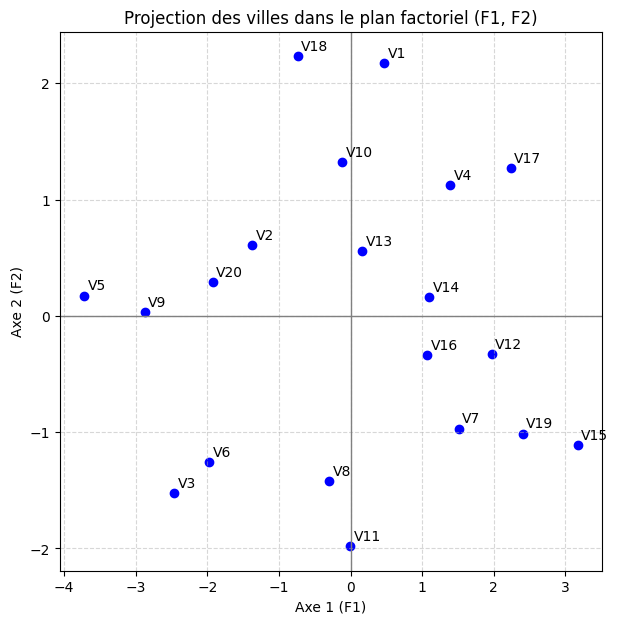

Interprétation du nuage de points :
- Les villes proches sur le graphique ont des profils sportifs similaires.
- Les villes situées de part et d'autre de l'axe F1 ou F2 sont opposées
  par rapport aux caractéristiques portées par ces axes.
- Les villes très éloignées du centre (0,0) ont un profil plus 'marqué',
  tandis que celles proches de l'origine sont plus moyennes.



In [13]:
# ============================================================
# Q8 : REPRESENTATION GRAPHIQUE DES VILLES DANS LE SOUS-ESPACE
# ============================================================
titre_question("Q8 : REPRESENTATION GRAPHIQUE DES VILLES DANS LE SOUS-ESPACE")

# Théorie :
# - On a retenu nb_axes axes factoriels à la Q5.
# - Si nb_axes >= 2, on peut représenter les individus dans le plan (F1, F2).
# - Chaque ville i est représentée par le point de coordonnées (F_i1, F_i2).
# - On trace aussi les droites x = 0 et y = 0 qui sont les axes F1 et F2.

if nb_axes >= 2:
    print("On dispose d'au moins deux axes principaux : on construit le plan (F1, F2).\n")

    plt.figure(figsize=(7,7))
    plt.scatter(F[:, 0], F[:, 1], color='blue')

    # étiquettes des villes (V1, V2, ..., Vn)
    for i in range(n):
        plt.text(F[i, 0] + 0.05, F[i, 1] + 0.05, f"V{i+1}")

    # axes du plan factoriel
    plt.axhline(0, color='grey', linewidth=1)
    plt.axvline(0, color='grey', linewidth=1)

    plt.xlabel("Axe 1 (F1)")
    plt.ylabel("Axe 2 (F2)")
    plt.title("Projection des villes dans le plan factoriel (F1, F2)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    print("Interprétation du nuage de points :")
    print("- Les villes proches sur le graphique ont des profils sportifs similaires.")
    print("- Les villes situées de part et d'autre de l'axe F1 ou F2 sont opposées")
    print("  par rapport aux caractéristiques portées par ces axes.")
    print("- Les villes très éloignées du centre (0,0) ont un profil plus 'marqué',")
    print("  tandis que celles proches de l'origine sont plus moyennes.\n")

else:
    print("Moins de deux axes retenus : on ne peut pas construire le plan (F1, F2).")

# Intérêt :
# - Visualiser la structure des données (groupes de villes, oppositions).
# - Faciliter l'interprétation des axes F1 et F2 en observant la position des villes.


In [14]:
# Q9) ANALYSE DU NUAGE DES INDIVIDUS
# ========================================
titre_question("Q9) Analyse du nuage des villes dans le plan (F1, F2)")

print("Commentaire Q9 :")
print("- Les villes situées à gauche du plan (F1 fortement négatif), comme V3, V5, V6 ou V9,")
print("  correspondent à des profils où le niveau global de pratique des sports considérés est relativement plus faible.")
print("- À l’inverse, les villes situées à droite (F1 positif), comme V15, V19, V12, V7 ou V16,")
print("  présentent des profils plus élevés sur les sports les plus corrélés positivement avec F1.")
print("- Sur l’axe vertical F2, certaines villes comme V1 et V18 sont en haut du plan,")
print("  ce qui traduit une sur‑représentation des sports associés positivement à F2.")
print("- La ville V11 se trouve en bas du plan (F2 très négatif), ce qui indique un comportement sportif opposé")
print("  à celui des villes en haut pour les variables fortement chargées sur F2.")
print("- Les villes proches les unes des autres (par exemple V2 et V20, ou encore V7, V12 et V16)")
print("  ont des profils sportifs très similaires, tandis que des villes éloignées comme V3 et V15")
print("  ont des profils très différents dans l’ensemble des sports étudiés.")



### Q9) Analyse du nuage des villes dans le plan (F1, F2) ###

Commentaire Q9 :
- Les villes situées à gauche du plan (F1 fortement négatif), comme V3, V5, V6 ou V9,
  correspondent à des profils où le niveau global de pratique des sports considérés est relativement plus faible.
- À l’inverse, les villes situées à droite (F1 positif), comme V15, V19, V12, V7 ou V16,
  présentent des profils plus élevés sur les sports les plus corrélés positivement avec F1.
- Sur l’axe vertical F2, certaines villes comme V1 et V18 sont en haut du plan,
  ce qui traduit une sur‑représentation des sports associés positivement à F2.
- La ville V11 se trouve en bas du plan (F2 très négatif), ce qui indique un comportement sportif opposé
  à celui des villes en haut pour les variables fortement chargées sur F2.
- Les villes proches les unes des autres (par exemple V2 et V20, ou encore V7, V12 et V16)
  ont des profils sportifs très similaires, tandis que des villes éloignées comme V3 et V15
  ont des profi

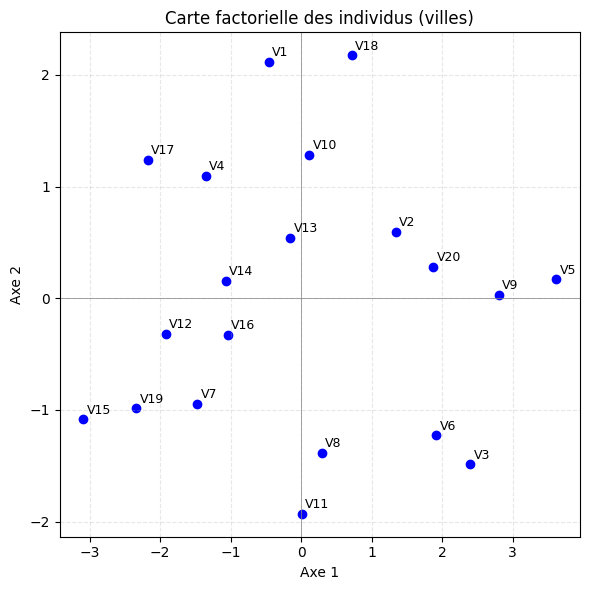

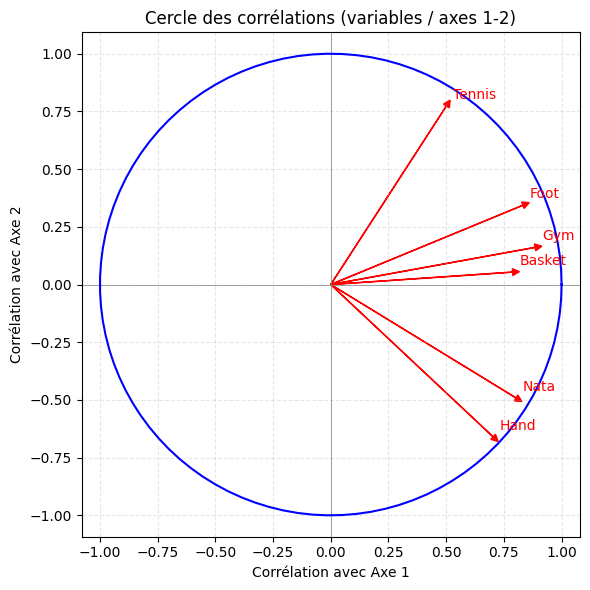

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ========================================
# DONNÉES
# ========================================
X = np.array([
    [1881.9,  96.8, 14.2, 25.2, 1135.5, 278.3],
    [3369.8,  96.8, 10.8, 51.6, 1331.7, 284.0],
    [4467.4, 138.2,  9.5, 34.2, 2346.1, 312.3],
    [1862.1,  83.2,  8.8, 27.6,  972.6, 203.4],
    [3499.8, 287.0, 11.5, 49.4, 2139.4, 358.0],
    [3903.2, 170.7,  6.3, 42.0, 1935.2, 292.9],
    [2620.7, 129.5,  4.2, 16.8, 1346.0, 131.8],
    [3678.4, 157.0,  6.0, 24.9, 1682.6, 194.2],
    [3840.5, 187.9, 10.2, 39.6, 1859.9, 449.1],
    [2170.2, 140.5, 11.7, 31.1, 1351.1, 256.5],
    [3920.4, 128.0,  7.2, 25.5, 1911.5,  64.1],
    [2599.6,  39.6,  5.5, 19.4, 1050.8, 172.5],
    [2828.5, 211.3,  9.9, 21.8, 1085.0, 209.0],
    [2498.7, 123.2,  7.4, 26.5, 1086.2, 153.5],
    [2685.1,  41.2,  2.3, 10.6,  812.5,  89.8],
    [2739.3, 100.7,  6.6, 22.0, 1270.4, 180.5],
    [1662.1,  81.1, 10.1, 19.1,  872.2, 123.3],
    [2469.9, 142.9, 15.5, 30.9, 1165.5, 335.5],
    [2350.7,  38.7,  2.4, 13.5, 1253.1, 170.0],
    [3177.7, 292.1,  8.0, 34.8, 1400.0, 358.9]
])

villes = [f'V{i+1}' for i in range(20)]
sports = ['Hand', 'Basket', 'Tennis', 'Gym', 'Nata', 'Foot']

# ========================================
# 1) CENTRAGE-RÉDUCTION
# ========================================
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0, ddof=1)
Xc = (X - X_mean) / X_std

# ========================================
# 2) ACP SUR LES DONNÉES CENTRÉES-RÉDUITES
# ========================================
pca = PCA(n_components=2)
F = pca.fit_transform(Xc)          # coordonnées des individus (villes) sur les axes 1 et 2
# Corrélations variables / axes (cercle des corrélations)
corvar = pca.components_.T * np.sqrt(pca.explained_variance_)

# ========================================
# 3) CARTE FACTORIELLE DES INDIVIDUS
# ========================================
plt.figure(figsize=(6, 6))
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)

for i in range(F.shape[0]):
    plt.scatter(F[i, 0], F[i, 1], color='blue')
    plt.text(F[i, 0] + 0.05, F[i, 1] + 0.05, villes[i], fontsize=9)

plt.xlabel("Axe 1")
plt.ylabel("Axe 2")
plt.title("Carte factorielle des individus (villes)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ========================================
# 4) CERCLE DES CORRÉLATIONS (VARIABLES)
# ========================================
plt.figure(figsize=(6, 6))
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)

# flèches pour chaque variable
for j in range(corvar.shape[0]):
    plt.arrow(0, 0,
              corvar[j, 0], corvar[j, 1],
              head_width=0.03, head_length=0.03, fc='red', ec='red')
    plt.text(corvar[j, 0] + 0.03, corvar[j, 1] + 0.03, sports[j], color='red')

# cercle unité
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), color='blue')

plt.xlabel("Corrélation avec Axe 1")
plt.ylabel("Corrélation avec Axe 2")
plt.title("Cercle des corrélations (variables / axes 1-2)")
plt.axis('equal')
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


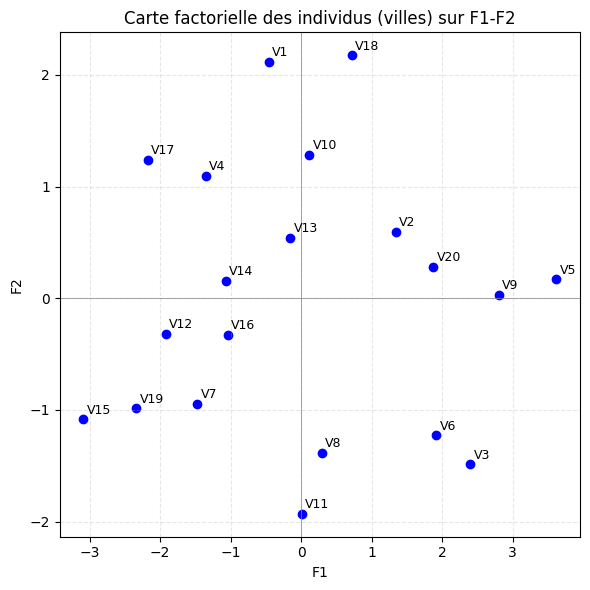

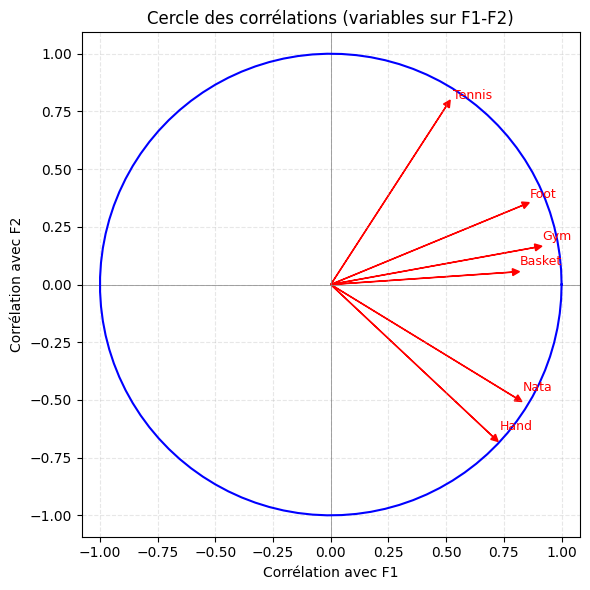

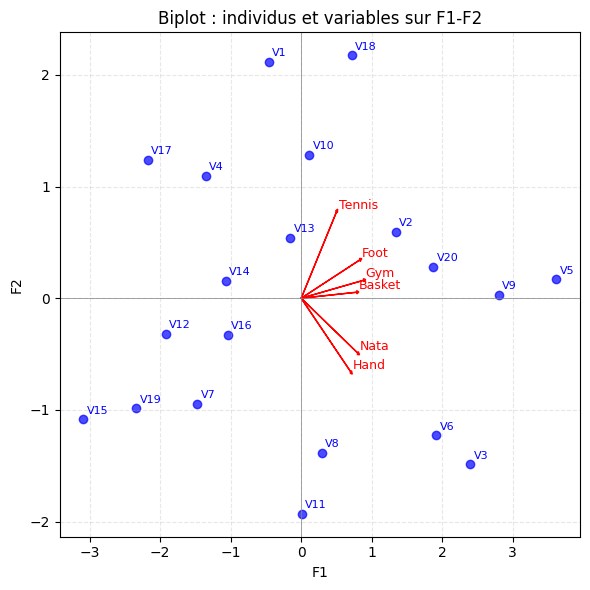

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ========================================
# DONNÉES
# ========================================
X = np.array([
    [1881.9,  96.8, 14.2, 25.2, 1135.5, 278.3],
    [3369.8,  96.8, 10.8, 51.6, 1331.7, 284.0],
    [4467.4, 138.2,  9.5, 34.2, 2346.1, 312.3],
    [1862.1,  83.2,  8.8, 27.6,  972.6, 203.4],
    [3499.8, 287.0, 11.5, 49.4, 2139.4, 358.0],
    [3903.2, 170.7,  6.3, 42.0, 1935.2, 292.9],
    [2620.7, 129.5,  4.2, 16.8, 1346.0, 131.8],
    [3678.4, 157.0,  6.0, 24.9, 1682.6, 194.2],
    [3840.5, 187.9, 10.2, 39.6, 1859.9, 449.1],
    [2170.2, 140.5, 11.7, 31.1, 1351.1, 256.5],
    [3920.4, 128.0,  7.2, 25.5, 1911.5,  64.1],
    [2599.6,  39.6,  5.5, 19.4, 1050.8, 172.5],
    [2828.5, 211.3,  9.9, 21.8, 1085.0, 209.0],
    [2498.7, 123.2,  7.4, 26.5, 1086.2, 153.5],
    [2685.1,  41.2,  2.3, 10.6,  812.5,  89.8],
    [2739.3, 100.7,  6.6, 22.0, 1270.4, 180.5],
    [1662.1,  81.1, 10.1, 19.1,  872.2, 123.3],
    [2469.9, 142.9, 15.5, 30.9, 1165.5, 335.5],
    [2350.7,  38.7,  2.4, 13.5, 1253.1, 170.0],
    [3177.7, 292.1,  8.0, 34.8, 1400.0, 358.9]
])

villes = [f'V{i+1}' for i in range(20)]
sports = ['Hand', 'Basket', 'Tennis', 'Gym', 'Nata', 'Foot']

# ========================================
# 1) CENTRAGE-RÉDUCTION
# ========================================
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0, ddof=1)
Xc = (X - X_mean) / X_std

# ========================================
# 2) ACP SUR LES DONNÉES CENTRÉES-RÉDUITES
# ========================================
pca = PCA(n_components=2)
F = pca.fit_transform(Xc)          # coordonnées des individus (villes) sur F1,F2
# Corrélations variables / axes (cercle)
corvar = pca.components_.T * np.sqrt(pca.explained_variance_)

# ========================================
# 3) GRAPHE DES INDIVIDUS (F1,F2)
# ========================================
plt.figure(figsize=(6, 6))
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)

for i in range(F.shape[0]):
    plt.scatter(F[i, 0], F[i, 1], color='blue')
    plt.text(F[i, 0] + 0.05, F[i, 1] + 0.05, villes[i], fontsize=9)

plt.xlabel("F1")
plt.ylabel("F2")
plt.title("Carte factorielle des individus (villes) sur F1-F2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ========================================
# 4) GRAPHE DES VARIABLES (CERCLE DE CORRÉLATION)
# ========================================
plt.figure(figsize=(6, 6))
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)

for j in range(corvar.shape[0]):
    plt.arrow(0, 0,
              corvar[j, 0], corvar[j, 1],
              head_width=0.03, head_length=0.03, fc='red', ec='red')
    plt.text(corvar[j, 0] + 0.03, corvar[j, 1] + 0.03, sports[j],
             color='red', fontsize=9)

# cercle unité
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), color='blue')

plt.xlabel("Corrélation avec F1")
plt.ylabel("Corrélation avec F2")
plt.title("Cercle des corrélations (variables sur F1-F2)")
plt.axis('equal')
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ========================================
# 5) BIPLOT : INDIVIDUS + VARIABLES
# ========================================
plt.figure(figsize=(6, 6))
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)

# individus
for i in range(F.shape[0]):
    plt.scatter(F[i, 0], F[i, 1], color='blue', alpha=0.7)
    plt.text(F[i, 0] + 0.05, F[i, 1] + 0.05, villes[i],
             fontsize=8, color='blue')

# variables (flèches, mêmes coordonnées que cercle)
for j in range(corvar.shape[0]):
    plt.arrow(0, 0,
              corvar[j, 0], corvar[j, 1],
              head_width=0.03, head_length=0.03, fc='red', ec='red')
    plt.text(corvar[j, 0] + 0.03, corvar[j, 1] + 0.03, sports[j],
             color='red', fontsize=9)

plt.xlabel("F1")
plt.ylabel("F2")
plt.title("Biplot : individus et variables sur F1-F2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()
